# IoT Intrusion Detection - Logistic Regression V2

This notebook trains a second logistic regression model as an independent experiment.

Goal:
- keep the same task and evaluation style as the first notebook
- change the model and hyperparameters
- save the V2 model and its metrics separately

This notebook does not compare against your friend's model inside the notebook.
It only builds and evaluates `logistic_regression_v2`.

## Setup

In [21]:
%reload_ext autoreload
%autoreload 2

from pathlib import Path
from src.config import DATASET_PATH

import json
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
from sklearn.linear_model import LogisticRegression

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import BASELINE_DIR, RANDOM_STATE, SPLITS_DIR
from src.data_pipeline import (
    clean_dataset,
    fit_preprocessor,
    load_artifacts,
    load_dataset,
    load_split,
    save_artifacts,
    save_splits,
    split_dataset,
    transform_features,
)
from src.schema import LABEL_COLUMN
from src.evaluation import (
    evaluate,
    per_class_dataframe,
    plot_confusion_matrix,
    save_baseline,
    timed,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

MODEL_NAME = "logistic_regression_v2"
PARAMS_PATH = BASELINE_DIR / f"{MODEL_NAME}_params.json"
TARGET_ROWS_WHEN_SPLITS_MISSING = 600_000
V2_PREPROCESSING_DIR = PROJECT_ROOT / "models" / "preprocessing_v2"
V2_SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits_v2"

## 1. Load saved splits if they exist, otherwise build a memory-safe sample

This keeps the notebook usable even if `data/processed/splits/` is not present in the repo clone.

If the main saved splits are missing, the notebook does not read the full parquet into pandas.
Instead, it uses PyArrow to read the dataset in batches, draws a stratified working sample, then builds preprocessing and train/val/test splits from that sample.

Important:
- if your friend's saved preprocessing and splits already exist, this notebook only reads them
- if this notebook has to build its own artifacts, it saves them into `models/preprocessing_v2/` and `data/processed/splits_v2/`
- that keeps your friend's preprocessing files untouched

In [22]:
train_path = SPLITS_DIR / "train.parquet"
val_path = SPLITS_DIR / "val.parquet"
test_path = SPLITS_DIR / "test.parquet"
v2_train_path = V2_SPLITS_DIR / "train.parquet"
v2_val_path = V2_SPLITS_DIR / "val.parquet"
v2_test_path = V2_SPLITS_DIR / "test.parquet"

if train_path.exists() and val_path.exists() and test_path.exists():
    print("Loading your friend's existing preprocessing artifacts and transformed splits...")
    artifacts = load_artifacts()
    X_train, y_train, _ = load_split("train")
    X_val, y_val, _ = load_split("val")
    X_test, y_test, _ = load_split("test")
elif v2_train_path.exists() and v2_val_path.exists() and v2_test_path.exists():
    print("Loading previously saved V2 preprocessing artifacts and transformed splits...")
    artifacts = load_artifacts(input_dir=V2_PREPROCESSING_DIR)
    X_train, y_train, _ = load_split("train", input_dir=V2_SPLITS_DIR)
    X_val, y_val, _ = load_split("val", input_dir=V2_SPLITS_DIR)
    X_test, y_test, _ = load_split("test", input_dir=V2_SPLITS_DIR)
else:
    print(f"Saved splits not found. Building V2-only sample artifacts from {DATASET_PATH}...")
    parquet_file = pq.ParquetFile(DATASET_PATH)

    total_rows = 0
    for batch in parquet_file.iter_batches(columns=[LABEL_COLUMN], batch_size=200_000):
        total_rows += batch.num_rows

    sample_frac = min(1.0, TARGET_ROWS_WHEN_SPLITS_MISSING / total_rows)
    sampled_chunks = []
    for batch in parquet_file.iter_batches(batch_size=200_000):
        chunk = batch.to_pandas(split_blocks=True, self_destruct=True)
        chunk = clean_dataset(chunk)
        if sample_frac < 1.0:
            chunk = (
                chunk.groupby(LABEL_COLUMN, group_keys=False)
                     .sample(frac=sample_frac, random_state=RANDOM_STATE)
                     .reset_index(drop=True)
            )
        sampled_chunks.append(chunk)

    df = pd.concat(sampled_chunks, ignore_index=True)
    print(f"Working sample shape: {df.shape}")

    splits = split_dataset(df)
    artifacts = fit_preprocessor(splits.X_train, splits.y_train)

    X_train = transform_features(artifacts.preprocessor, splits.X_train)
    X_val = transform_features(artifacts.preprocessor, splits.X_val)
    X_test = transform_features(artifacts.preprocessor, splits.X_test)

    y_train = splits.y_train
    y_val = splits.y_val
    y_test = splits.y_test

    transformed_splits = type(splits)(
        X_train=X_train,
        X_val=X_val,
        X_test=X_test,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
    )

    save_artifacts(artifacts, output_dir=V2_PREPROCESSING_DIR)
    save_splits(transformed_splits, artifacts.label_encoder, output_dir=V2_SPLITS_DIR)
    print(f"Saved V2 preprocessing to: {V2_PREPROCESSING_DIR}")
    print(f"Saved V2 splits to: {V2_SPLITS_DIR}")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Classes: {len(artifacts.label_encoder.classes_)}")

Loading your friend's existing preprocessing artifacts and transformed splits...
X_train: (419988, 47)   y_train: (419988,)
X_val:   (89998, 47)   y_val:   (89998,)
X_test:  (89998, 47)   y_test:  (89998,)
Classes: 34


## 2. Define the V2 model

The first notebook used `SGDClassifier(loss="log_loss")`, which behaves like logistic regression trained with stochastic optimization.

This V2 notebook switches to `LogisticRegression` with the `lbfgs` solver and stronger regularization tuning.
That gives us a genuinely different linear baseline while staying in the logistic-regression family.

In [25]:
model = LogisticRegression(
    solver="lbfgs",
    C=2.0,
    max_iter=1000,
    class_weight=artifacts.class_weights,
    random_state=RANDOM_STATE,
)

model.get_params()

{'C': 2.0,
 'class_weight': {'Backdoor_Malware': 53.37276669104587,
  'BenignTraffic': 0.6009382919521996,
  'BrowserHijacking': 29.30881994348581,
  'CommandInjection': 31.738967675794903,
  'DDoS-ACK_Fragmentation': 0.6022631848408116,
  'DDoS-HTTP_Flood': 5.964147798751317,
  'DDoS-ICMP_Flood': 0.6009563194699951,
  'DDoS-ICMP_Fragmentation': 0.6009292785988886,
  'DDoS-PSHACK_Flood': 0.6009653336345038,
  'DDoS-RSTFINFlood': 0.6009533148085842,
  'DDoS-SYN_Flood': 0.6009262742078688,
  'DDoS-SlowLoris': 7.329885997575027,
  'DDoS-SynonymousIP_Flood': 0.6009443010046213,
  'DDoS-TCP_Flood': 0.6009623288829544,
  'DDoS-UDP_Flood': 0.6009563194699951,
  'DDoS-UDP_Fragmentation': 0.6007610789527534,
  'DNS_Spoofing': 0.9597440899114104,
  'DictionaryBruteForce': 13.143299134853503,
  'DoS-HTTP_Flood': 2.3893344714886253,
  'DoS-SYN_Flood': 0.6009202655159525,
  'DoS-TCP_Flood': 0.600917261215055,
  'DoS-UDP_Flood': 0.6009292785988886,
  'MITM-ArpSpoofing': 0.6009563194699951,
  'Mirai-

## 3. Train the V2 model

In [26]:
with timed("Training logistic_regression_v2"):
    model.fit(X_train, y_train)

print(f"Train accuracy: {model.score(X_train, y_train):.4f}")

C:\Users\user\miniconda3\envs\esibml\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training logistic_regression_v2: 937.6s
Train accuracy: 0.7790


## 4. Evaluate on validation

In [27]:
val_metrics = evaluate(model, X_val, y_val, artifacts.label_encoder, split_name="val")

print("Validation metrics")
print(f"  accuracy    = {val_metrics.accuracy:.4f}")
print(f"  macro_f1    = {val_metrics.macro_f1:.4f}")
print(f"  weighted_f1 = {val_metrics.weighted_f1:.4f}")

Validation metrics
  accuracy    = 0.7786
  macro_f1    = 0.5708
  weighted_f1 = 0.7865


In [31]:
per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Uploading_Attack,0.0090,0.3000,0.0174,20.0000
Recon-PingSweep,0.0174,0.3143,0.0330,35.0000
XSS,0.0197,0.1864,0.0357,59.0000
Backdoor_Malware,0.0199,0.1837,0.0359,49.0000
BrowserHijacking,0.0229,0.2667,0.0421,90.0000
SqlInjection,0.0293,0.3333,0.0539,81.0000
CommandInjection,0.0766,0.2289,0.1148,83.0000
Recon-OSScan,0.2695,0.0799,0.1233,"1,514.0000"
DictionaryBruteForce,0.0932,0.2388,0.1341,201.0000
Recon-PortScan,0.4464,0.1972,0.2735,"1,268.0000"


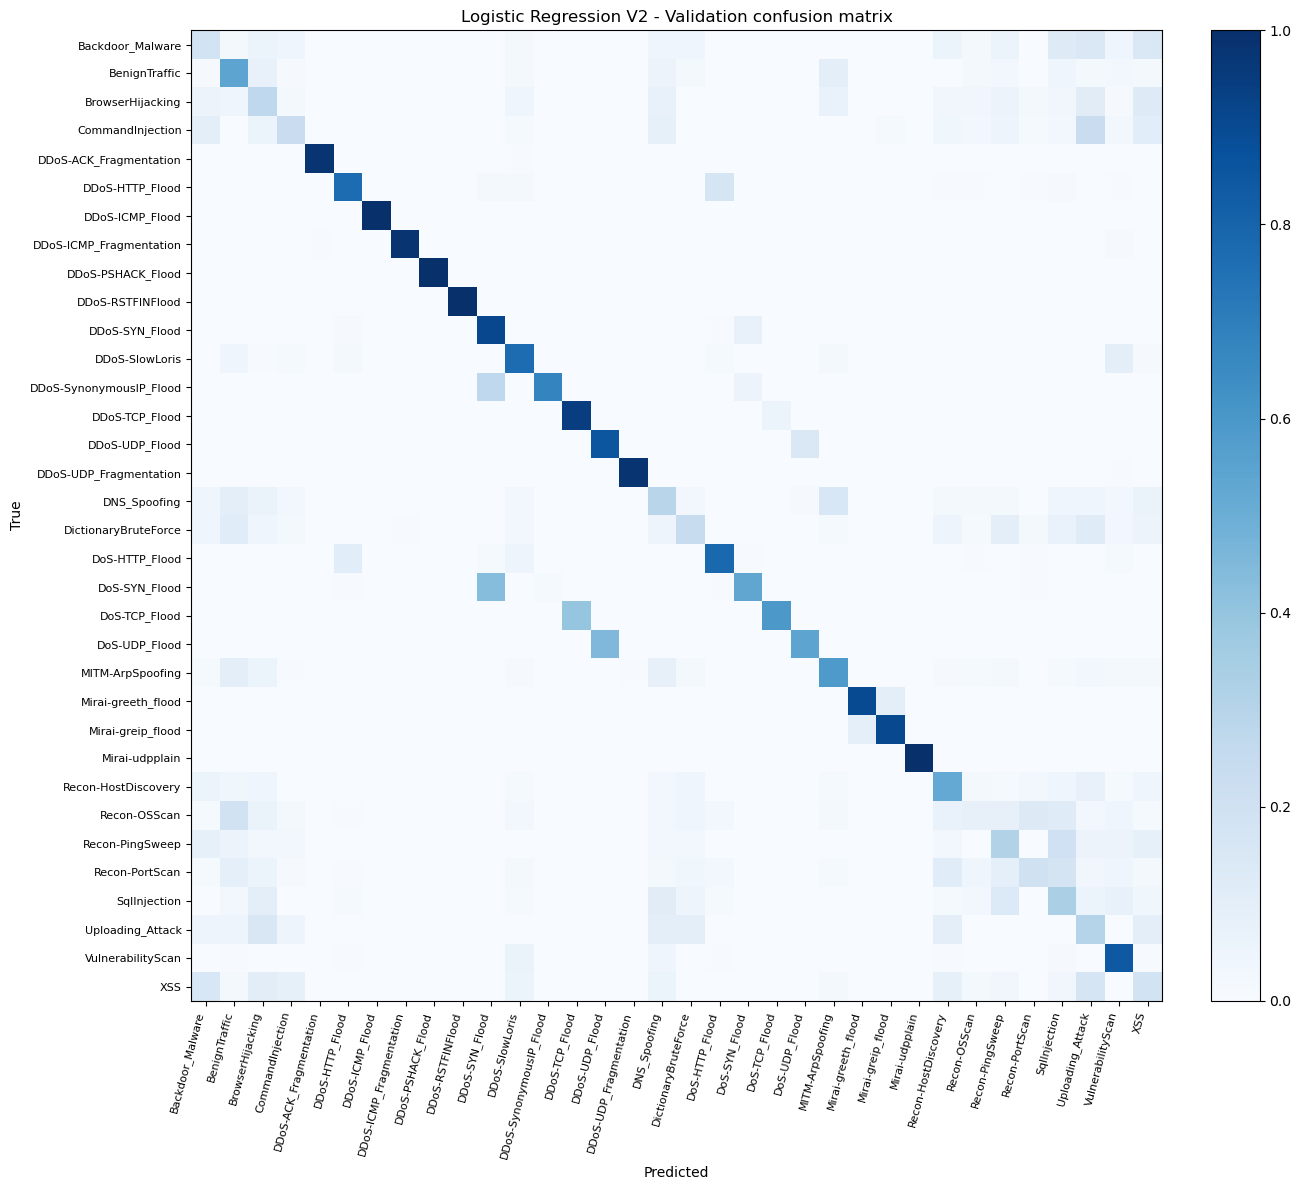

In [32]:
plot_confusion_matrix(
    model,
    X_val,
    y_val,
    artifacts.label_encoder,
    title="Logistic Regression V2 - Validation confusion matrix",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_val.png",
)
plt.show()

## 5. Evaluate on test

In [33]:
test_metrics = evaluate(model, X_test, y_test, artifacts.label_encoder, split_name="test")

print("Test metrics")
print(f"  accuracy    = {test_metrics.accuracy:.4f}")
print(f"  macro_f1    = {test_metrics.macro_f1:.4f}")
print(f"  weighted_f1 = {test_metrics.weighted_f1:.4f}")

Test metrics
  accuracy    = 0.7802
  macro_f1    = 0.5716
  weighted_f1 = 0.7879


In [34]:
per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Uploading_Attack,0.0090,0.3000,0.0174,20.0000
Recon-PingSweep,0.0174,0.3143,0.0330,35.0000
XSS,0.0197,0.1864,0.0357,59.0000
Backdoor_Malware,0.0199,0.1837,0.0359,49.0000
BrowserHijacking,0.0229,0.2667,0.0421,90.0000
SqlInjection,0.0293,0.3333,0.0539,81.0000
CommandInjection,0.0766,0.2289,0.1148,83.0000
Recon-OSScan,0.2695,0.0799,0.1233,"1,514.0000"
DictionaryBruteForce,0.0932,0.2388,0.1341,201.0000
Recon-PortScan,0.4464,0.1972,0.2735,"1,268.0000"


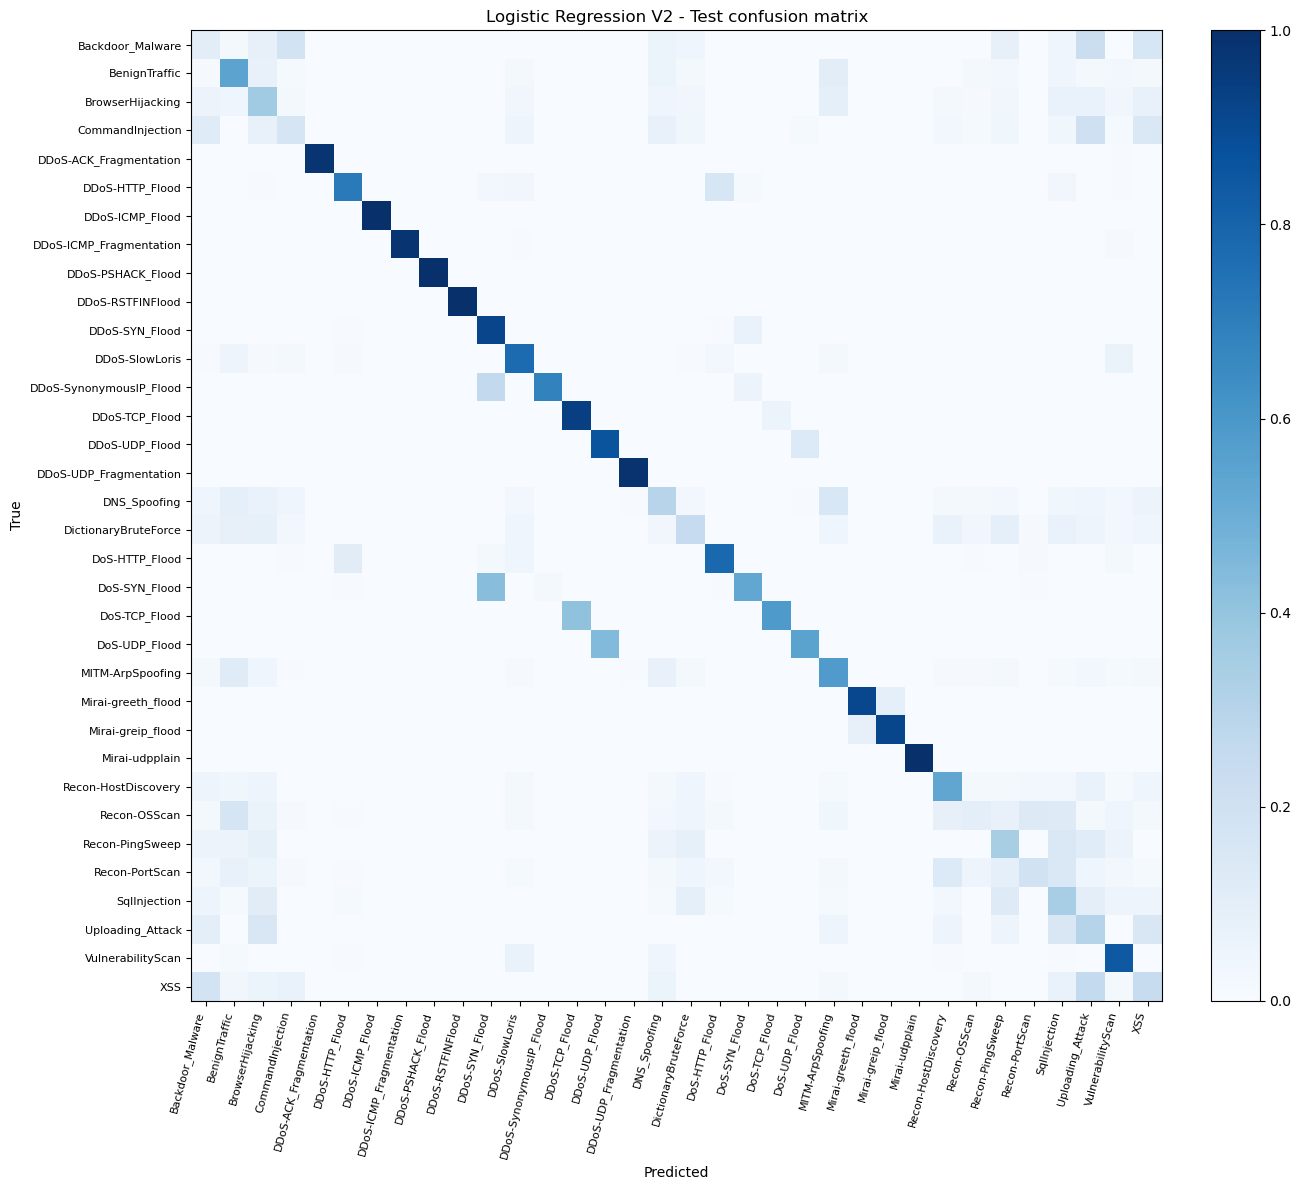

In [35]:
plot_confusion_matrix(
    model,
    X_test,
    y_test,
    artifacts.label_encoder,
    title="Logistic Regression V2 - Test confusion matrix",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_test.png",
)
plt.show()

## 6. Save the V2 artifacts

Everything is saved under `models/baseline/` but with the new name `logistic_regression_v2` so it stays independent from the first notebook.

In [36]:
save_baseline(model, [val_metrics, test_metrics], name=MODEL_NAME)
PARAMS_PATH.write_text(json.dumps(model.get_params(), indent=2, default=str))

print("Saved files:")
for path in sorted(BASELINE_DIR.glob(f"{MODEL_NAME}*")):
    size_kb = path.stat().st_size / 1024
    print(f"  {path.name:<42} ({size_kb:,.1f} KB)")

Saved files:
  logistic_regression_v2.joblib              (15.9 KB)
  logistic_regression_v2_confusion_test.png  (173.4 KB)
  logistic_regression_v2_confusion_val.png   (174.2 KB)
  logistic_regression_v2_metrics.json        (12.8 KB)
  logistic_regression_v2_params.json         (1.8 KB)


## 7. Notes for the later comparison notebook

When you are ready to compare with your friend's model later, the main files to read will be:
- `models/baseline/logistic_regression_metrics.json`
- `models/baseline/logistic_regression_v2_metrics.json`

That comparison can live in a separate notebook or script.